# Training a DQN with social attention on `intersection-v0`

In [2]:
from gymnasium.wrappers import RecordVideo
import numpy as np
import matplotlib.pyplot as plt
import sys, os

## Training

The training and testing pipeline is based on a social attention Double-DQN, developped by [[Leurent and Mercat, 2019]](https://arxiv.org/abs/1911.12250).


In [9]:
sys.path.insert(0, os.path.abspath("rl-agents"))

from rl_agents.trainer.evaluation import Evaluation
from rl_agents.agents.common.factory import load_agent, load_environment

NUM_EPISODES = 1000

# Chemin local vers le repo cloné
base_path = os.path.abspath("rl-agents/scripts")
env_config = os.path.join(base_path, "configs/HighwayEnv/env_obs_attention_with_traffic.json")
agent_config = os.path.join(base_path, "configs/HighwayEnv/agents/DQNAgent/ego_attention.json")
env = load_environment(env_config)
agent = load_agent(agent_config, env)

evaluation_ = Evaluation(
    env,
    agent,
    num_episodes=NUM_EPISODES,
    display_env=False,
    display_agent=False
)

print(f"Ready to train {agent} on {env}")

2026-04-06 16:56:20,147 [WARNING] rl_agents.agents.common.utils: Preferred device cuda:best unavailable, switching to default cpu


Ready to train <rl_agents.agents.deep_q_network.pytorch.DQNAgent object at 0x0000022B0FA52DB0> on <OrderEnforcing<PassiveEnvChecker<HighwayEnv<highway-v0>>>>


In [4]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir="{evaluation_.directory}" --port=6006

In [6]:
episode_rewards, all_losses, losses_steps, eval_steps, eval_means, eval_stds, durations,eval_duration_means, eval_duration_std, epsilons, returns = evaluation_.train()

in training


c:\Users\louis\Documents\3A\RL Apprentissage par Renforcement\projet_rl\Reinforcement_learning_highway\extension_task\social_attention\rl-agents\rl_agents\agents\deep_q_network\pytorch.py:80: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  return self.value_net(torch.tensor(states, dtype=torch.float).to(self.device)).data.cpu().numpy()
2026-04-04 17:12:03,002 [INFO] rl_agents.trainer.evaluation: Episode 0 score: 2.3
2026-04-04 17:12:03,012 [INFO] rl_agents.trainer.evaluation: Saved DQNAgent model to out\HighwayEnv\DQNAgent\run_20260404-171122_28896\checkpoint-0.tar
2026-04-04 17:12:03,893 [INFO] rl_agents.trainer.evaluation: Episode 1 score: 2.9
2026-04-04 17:12:03,899 [INFO] rl_agents.trainer.evaluation: Saved DQNAgent model to out\

In [ ]:
data = {
    "episode_rewards": episode_rewards,
    "all_losses": all_losses,
    "losses_steps": losses_steps,
    "eval_steps": eval_steps,
    "eval_means": eval_means,
    "eval_stds": eval_stds,
    "durations": durations,
    "eval_duration_means": eval_duration_means,
    "eval_duration_std": eval_duration_std,
    "epsilons": epsilons,
    "returns": returns,
}

np.save("training_logs.npy", data)

## Testing

In [3]:
data = np.load("training_logs.npy", allow_pickle=True).item()

episode_rewards = data["episode_rewards"]
all_losses = data["all_losses"]
losses_steps = data["losses_steps"]
eval_steps = data["eval_steps"]
eval_means = data["eval_means"]
eval_stds = data["eval_stds"]
durations = data["durations"]
eval_duration_means = data["eval_duration_means"]
eval_duration_std = data["eval_duration_std"]
epsilons = data["epsilons"]
returns = data["returns"]

In [10]:
env_config = os.path.join(base_path, "configs/HighwayEnv/env_obs_attention_with_traffic.json")
env = load_environment(env_config)
env = RecordVideo(env, video_folder="runs/videos", episode_trigger=lambda e: True)

agent = load_agent(agent_config, env)
sys.path.insert(0, os.path.abspath("rl-agents"))
evaluation_test = Evaluation(env, agent, num_episodes=20, training = False, recover = True)
evaluation_test.video_recorder = None
evaluation_test.test()

2026-04-06 16:56:26,695 [WARNING] rl_agents.agents.common.utils: Preferred device cuda:best unavailable, switching to default cpu
2026-04-06 16:56:26,978 [INFO] rl_agents.trainer.evaluation: Loaded DQNAgent model from out\HighwayEnv\DQNAgent\saved_models\latest.tar


2026-04-06 16:56:38,518 [INFO] rl_agents.trainer.evaluation: Episode 0 score: 17.3
2026-04-06 16:57:00,969 [INFO] rl_agents.trainer.evaluation: Episode 1 score: 33.8
2026-04-06 16:57:15,489 [INFO] rl_agents.trainer.evaluation: Episode 2 score: 30.8
2026-04-06 16:57:37,992 [INFO] rl_agents.trainer.evaluation: Episode 3 score: 55.2
2026-04-06 16:58:00,533 [INFO] rl_agents.trainer.evaluation: Episode 4 score: 55.4
2026-04-06 16:58:22,980 [INFO] rl_agents.trainer.evaluation: Episode 5 score: 54.8
2026-04-06 16:58:38,160 [INFO] rl_agents.trainer.evaluation: Episode 6 score: 36.1
2026-04-06 16:59:00,550 [INFO] rl_agents.trainer.evaluation: Episode 7 score: 57.0
2026-04-06 16:59:35,293 [INFO] rl_agents.trainer.evaluation: Episode 8 score: 55.0
2026-04-06 16:59:57,047 [INFO] rl_agents.trainer.evaluation: Episode 9 score: 49.1
2026-04-06 17:00:19,602 [INFO] rl_agents.trainer.evaluation: Episode 10 score: 54.4
2026-04-06 17:00:42,436 [INFO] rl_agents.trainer.evaluation: Episode 11 score: 56.3
20

The videos of the testing episodes are available in the runs foler.

## Plots du training

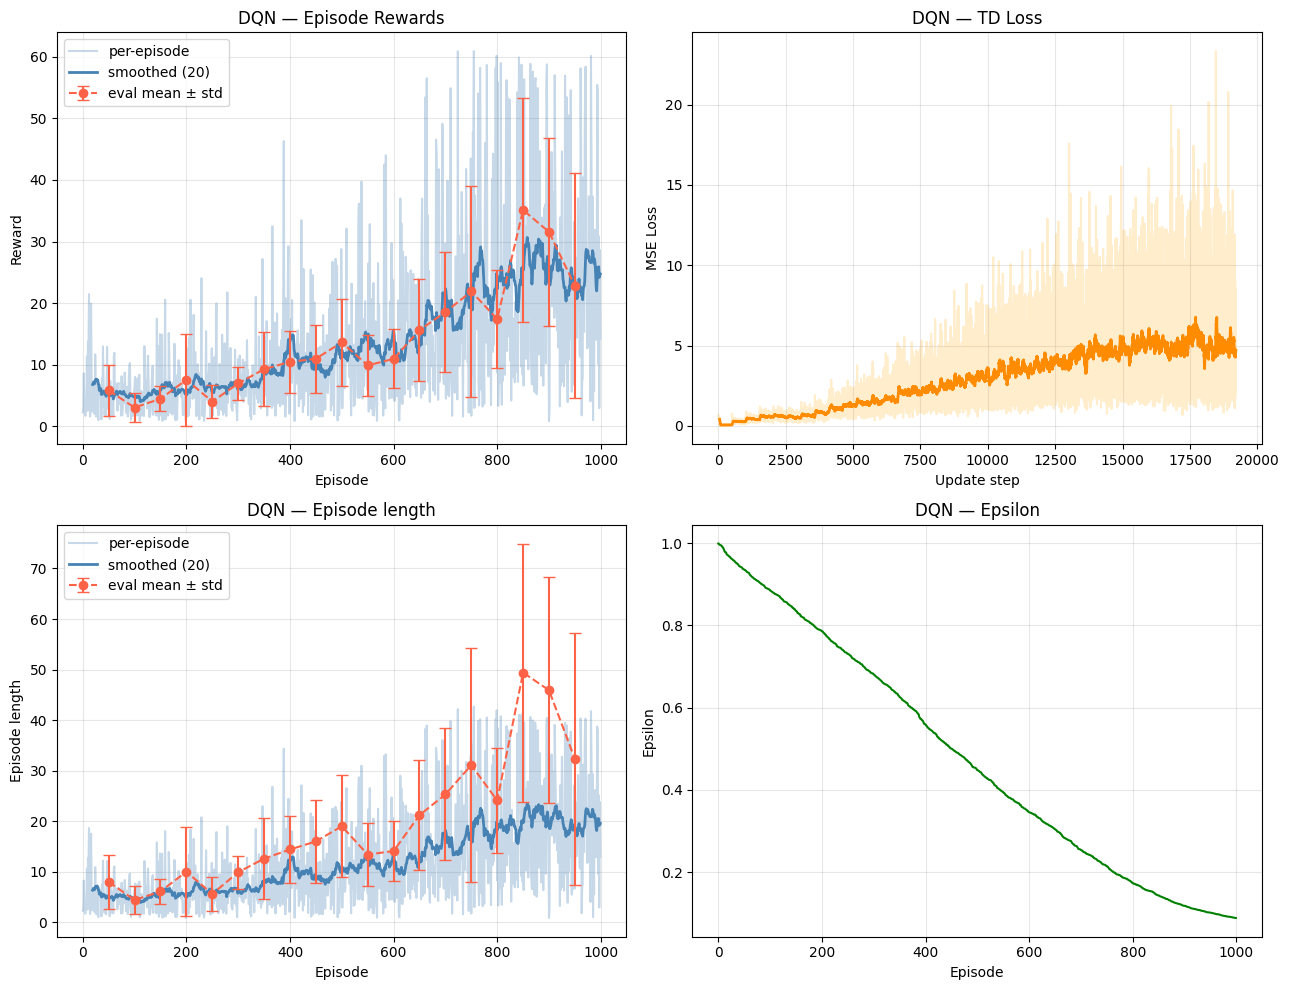

In [ ]:
def smooth(x, window=20):
    """Running mean for smoother visualisation."""
    return np.convolve(x, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Episode rewards
ax = axes[0][0]
ax.plot(episode_rewards, alpha=0.3, color='steelblue', label='per-episode')
ax.plot(range(19, len(episode_rewards)), smooth(episode_rewards), color='steelblue', lw=2, label='smoothed (20)')
# ax.plot(range(len(episode_rewards)), episode_rewards, color='steelblue', lw=2, label='smoothed (20)')
ax.errorbar(eval_steps, eval_means, yerr=eval_stds, fmt='o--', color='tomato',
            capsize=4, label='eval mean ± std')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title('DQN — Episode Rewards')
ax.legend()
ax.grid(alpha=0.3)

# TD Loss
# print(all_losses)
ax = axes[0][1]
ax.plot(all_losses, alpha=0.2, color='orange')
if len(all_losses) > 50:
    ax.plot(range(49, len(all_losses)), smooth(all_losses, 50), color='darkorange', lw=2)
ax.set_xlabel('Update step')
ax.set_ylabel('MSE Loss')
ax.set_title('DQN — TD Loss')
ax.grid(alpha=0.3)

# Episode returns
ax = axes[1][0]
ax.plot(returns, alpha=0.3, color='steelblue', label='per-episode')
ax.plot(range(19, len(returns)), smooth(returns), color='steelblue', lw=2, label='smoothed (20)')
# ax.plot(range(len(durations)), durations, color='steelblue', lw=2, label='smoothed (20)')
ax.errorbar(eval_steps, eval_duration_means, yerr=eval_duration_std, fmt='o--', color='tomato',
            capsize=4, label='eval mean ± std')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode length')
ax.set_title('DQN — Episode length')
ax.legend()
ax.grid(alpha=0.3)

# TD Loss
ax = axes[1][1]
ax.plot(epsilons, color='green')
ax.set_xlabel('Episode')
ax.set_ylabel('Epsilon')
ax.set_title('DQN — Epsilon')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('social_attention_training_curves.png', dpi=120)
plt.show()

# episode_rewards, all_losses, eval_steps, eval_means, eval_stds, durations